In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

## Magnetfeld Kalibration

6.1 0.19999999999999998
13.4 0.3741657386773941
19.5 0.31622776601683794
22.4 0.58309518948453
24.1 0.2
25.4 0.3741657386773941


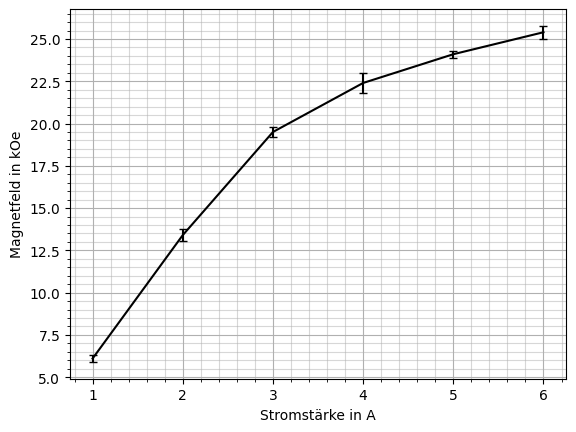

In [60]:
# Magnetfelddaten aus dem Laborbuch
H = np.array(
    [[6, 6, 6, 6.5, 6],     # 1A
    [13,14,13,13.5,13.5],   # 2A
    [19,20,19.5,19.5,19.5], # 3A
    [22,23,22.5,23,21.5],   # 4A
    [24,24,24,24,24.5],     # 5A
    [25,25.5,25.5,25,26]]  # 6A
)                           # H in kOe

I = np.array([1, 2, 3, 4, 5, 6]) # A
Hm = []
Hstd = []
for i in I-1: # um zu indizieren
    mean = np.mean(H[i,:])
    std = np.std(H[i,:], mean=mean)
    print(mean, std)
    Hm.append(mean)
    Hstd.append(std)


fig, ax = plt.subplots()
ax.errorbar(I, Hm, Hstd, fmt='k', capsize=3)

ax.set_xlabel('Stromstärke in A')
ax.set_ylabel('Magnetfeld in kOe')

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

plt.show()

## Neonspektrum

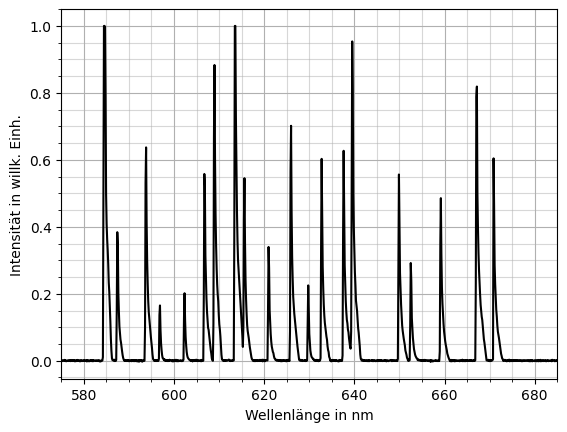

In [37]:
nm = np.loadtxt('../Messdaten/15122025_Zeeman/Spektrum_ThorLabs_2.csv', delimiter=',', skiprows=33, max_rows=3681-33)


fig, ax = plt.subplots()
ax.plot(nm[:,0], nm[:,1], 'k')

ax.set_xlabel('Wellenlänge in nm')
ax.set_ylabel('Intensität in willk. Einh.')

ax.set_xlim(575, 685)
ax.minorticks_on()

ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

plt.show()

In [4]:
dict = {
    9520: '585.2',
    9970: '587.2',
    10920: '588.1',
    12950: '607.4',
    13260: '609.6',
    14010: '614.3',
    14330: '616.3',
    15900: '626.6',
    17700: '638.2',
    16940: '632.8',
    18000: '640.2',
    19600: '650.6',
    22250: '667.8'
}

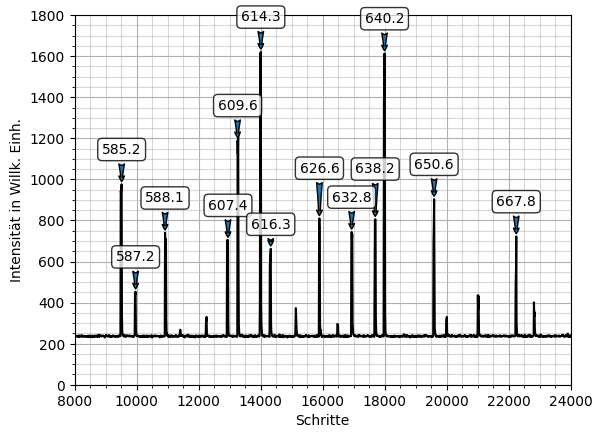

In [38]:
schritt = np.loadtxt('../Messdaten/15122025_Zeeman/schrittspektrum_500ms_win200_step10.dat', delimiter='\t')

fig, ax = plt.subplots()
ax.plot(schritt[:,0], schritt[:,1], 'k')

ax.set_xlabel("Schritte")
ax.set_ylabel("Intensität in Willk. Einh.")
ax.minorticks_on()

ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlim(8000, 24000)
ax.set_ylim(0,1800)

for step in list(dict):
    index = np.where(schritt[:,0] == step)
    y = schritt[index][0][1]
    if step == 14330:
        yt = y + 100
    elif step == 15900:
        yt = y+225
    elif step == 16940:
        yt = y + 150
    elif step == 17700:
        yt = y+225
    else:
        yt = y+150
    ax.annotate(dict[step], (step, y), (step, yt), arrowprops={'arrowstyle': 'fancy'}, ha='center', bbox={'boxstyle':'round', 'alpha':0.8, 'fc':'white', 'ec':'black'})

plt.show()

# Laserspektrum?

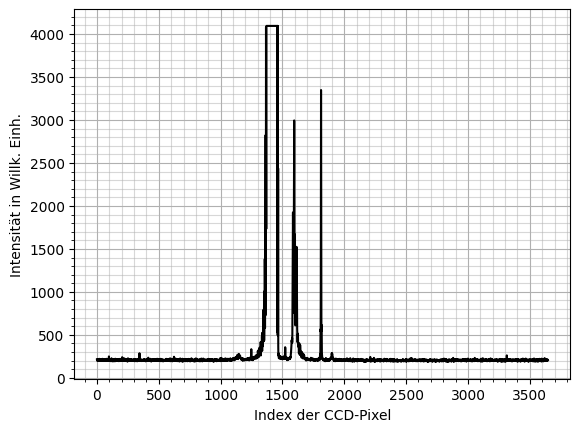

In [39]:
#laser = np.loadtxt('../Messdaten/15122025_Zeeman/500ms_Linsenjustage.dat', delimiter='\t')
longi = np.loadtxt('../Messdaten/15122025_Zeeman/500mslongitudinalemoden_gesehen.dat', delimiter='\t')
#gesehen = np.loadtxt('../Messdaten/15122025_Zeeman/Laser_gesehen.dat', delimiter='\t')


fig, ax = plt.subplots()
ax.plot(longi[:,0], longi[:,1], 'k', label='Longitudinalmoden')


ax.set_xlabel("Index der CCD-Pixel")
ax.set_ylabel("Intensität in Willk. Einh.")

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

plt.show()

## Variation der Spaltbreite

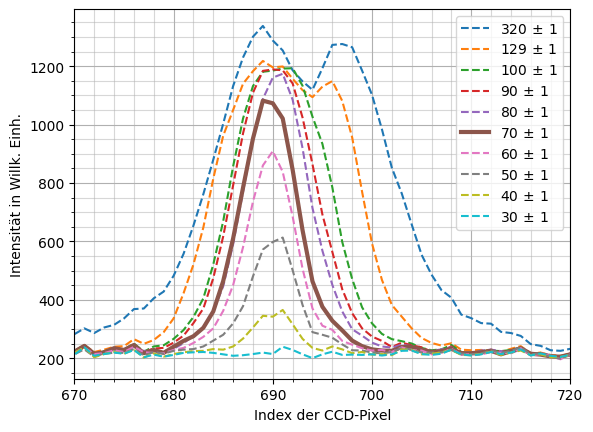

In [68]:
breiten = [320, 129, 100, 90, 80, 70, 60, 50 , 40, 30]

fig, ax = plt.subplots()

for breite in breiten:
    data = np.loadtxt(f'../Messdaten/15122025_Zeeman/6_dx_{breite}.dat', delimiter='\t')
    data[:,0]
    if breite != 70:
        ax.plot(data[:,0], data[:,1], '--', label=str(breite)+r'$\,\pm\,$1')
    else:
        ax.plot(data[:,0], data[:,1], '-', label=str(breite)+r'$\,\pm\,$1', lw=3)

ax.legend()
ax.set_xlabel("Index der CCD-Pixel")
ax.set_ylabel("Intensität in Willk. Einh.")
ax.set_xlim(670, 720)
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
plt.show()

## Polarisation der CCD

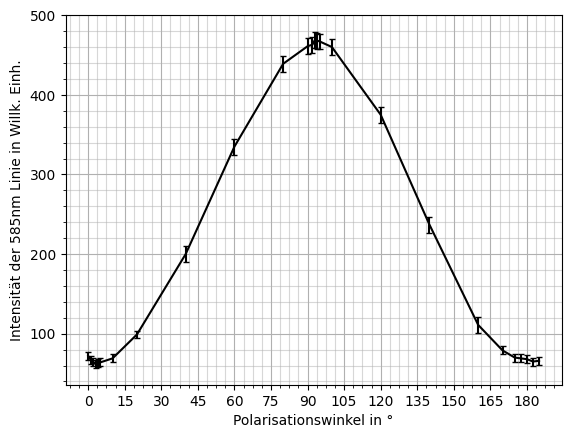

In [41]:
pol = {
0: 72,
1: 67,
2: 65,
3: 62,
4: 63,
5: 64,
10: 69,
20: 99,
40: 200,
60: 335,
80: 439,
90: 461,
92: 463,
93: 469,
94: 468,
95: 467,
100: 460,
120: 375,
140: 237,
160: 111,
170: 79,
175: 70,
177.5: 69,
180: 68,
182.5: 65,
185: 66
}
yerr = 8*[5]+12*[10]+6*[5]

fig, ax = plt.subplots()
ax.errorbar(list(pol), list(pol.values()), yerr=yerr, fmt='-k', capsize=2)

xticks = [0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180]
xlabels= [str(tick) for tick in xticks]
ax.set_xticks(xticks, labels=xlabels)

ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)
ax.set_xlabel('Polarisationswinkel in °')
ax.set_ylabel('Intensität der 585nm Linie in Willk. Einh.')

plt.show()

## $\lambda/2$-Plättchen

In [9]:
pol90 = """0 	367
1 	348
2 	342
3 	347
4 	340
5 	340
10 	296
15 	250
20 	201
25 	144
30 	100
35 	61
40 	50
41 	52
42 	49
43 	53
44 	49
45 	54
46 	53
47 	56
48 	60
49 	60
50 	63
55 	95
65 	201
75 	304
80 	343
82 	351
84 	360
85 	366
86 	359
87 	368
88 	355
89 	372
90 	354"""

pol0 = """0 	41
1 	47
2 	50
3 	53
4 	58
5 	58
10 	81
20 	176
30 	264
40 	320
41 	324
42 	324
43 	323
44 	323
45 	323
50 	304
60 	223
70 	125
80 	52
85 	47
86 	43
87 	43
88 	41
89 	43
90 	44"""

pol90 = {int(x[0]):int(x[1]) for x in [y.split() for y in pol90.split('\n')]}
pol0 = {int(x[0]):int(x[1]) for x in [y.split() for y in pol0.split('\n')]}

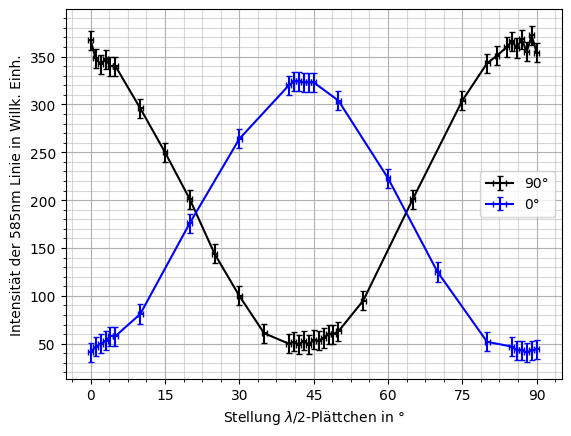

In [42]:
fig, ax = plt.subplots()
ax.errorbar(list(pol90), list(pol90.values()), yerr=10, xerr=0.5, fmt='-k', capsize=2, label='90°')
ax.errorbar(list(pol0), list(pol0.values()), yerr=10, xerr=0.5, fmt='-b', capsize=2, label='0°')

xticks = [0, 15, 30, 45, 60, 75, 90]
xlabels= [str(tick) for tick in xticks]
ax.set_xticks(xticks, labels=xlabels)

ax.set_xlabel(r'Stellung $\lambda/2$-Plättchen in °')
ax.set_ylabel('Intensität der 585nm Linie in Willk. Einh.')

ax.legend()
ax.minorticks_on()
ax.grid(which='major')
ax.grid(which='minor', alpha=0.5)

plt.show()

## Linienspektren

## 

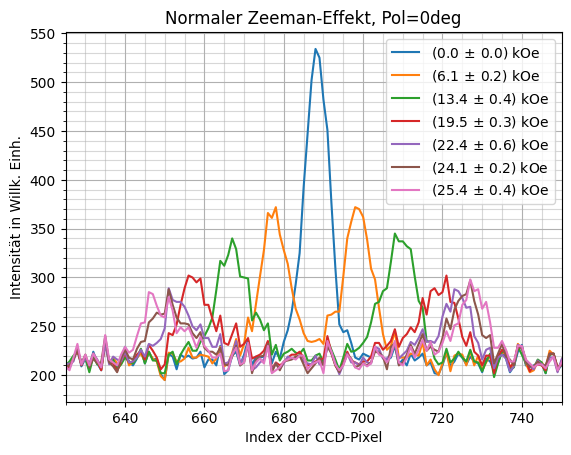

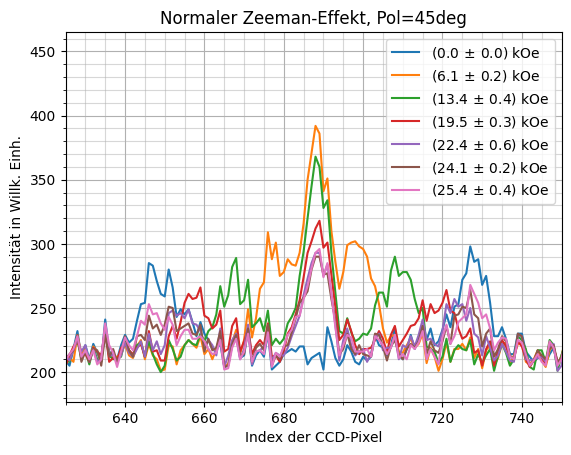

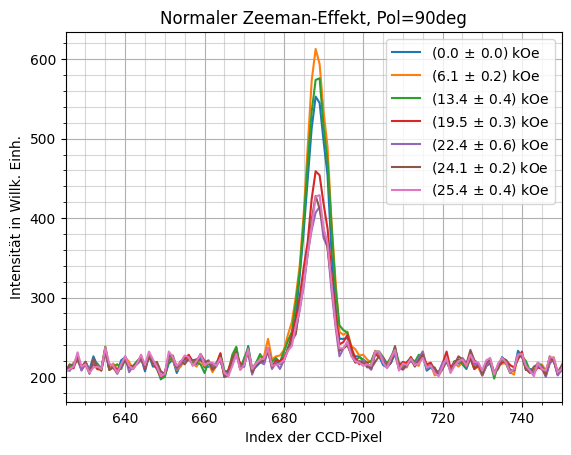

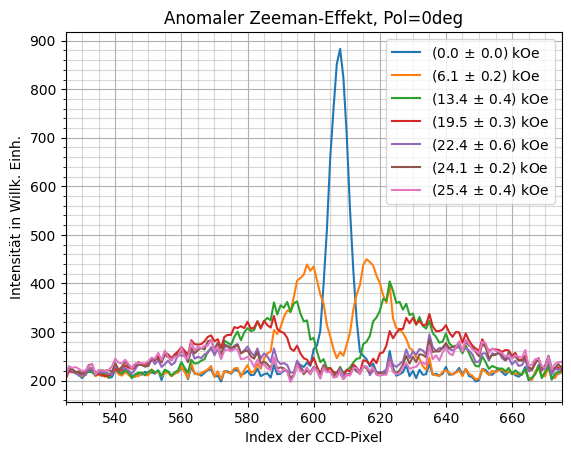

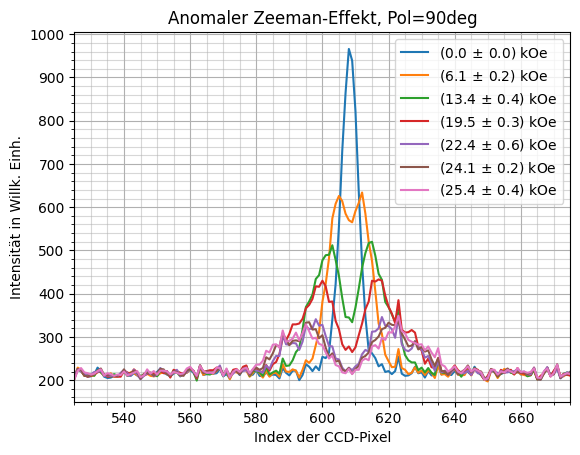

In [75]:
import os

curs = ['0A', '1A', '2A', '3A', '4A', '5A', '6A']

mags = [(00.0, 0.0),
        (06.1, 0.2),
        (13.4, 0.4),
        (19.5, 0.3),
        (22.4, 0.6),
        (24.1, 0.2),
        (25.4, 0.4)] # gerundete Magnetfelder + std für 0 bis 6 Ampère

filenames = ['9_0deg', '9_45deg', '9_90deg', '10_0deg', '10_90deg'] # dreimal normal, dreimal anomal

for filename in filenames:
    fig, ax = plt.subplots()
    
    ax.set_xlabel('Index der CCD-Pixel')
    ax.set_ylabel('Intensität in Willk. Einh.')
    ax.minorticks_on()
    ax.grid(which='major')
    ax.grid(which='minor', alpha=0.5)
    
    for i, cur in enumerate(curs):
        try:
            data = np.loadtxt(f'../Messdaten/15122025_Zeeman/{filename}_{cur}.dat', delimiter='\t')
        except:
            pass
        pol = filename.split('_')[1]
        if filename[0] == '9':
            ax.set_title(f'Normaler Zeeman-Effekt, Pol={pol}')
            ax.set_xlim(625, 750)
        else:
            ax.set_title(f'Anomaler Zeeman-Effekt, Pol={pol}')
            ax.set_xlim(525, 675)
        ax.plot(data[:,0], data[:,1], label=f'({mags[i][0]}'+r'$\,\pm\,$'+f'{mags[i][1]}) kOe')
    
    ax.legend()
        
        
    plt.show()